# Temporal Saliency Rescaling: fixing what raw saliency gets wrong

The [first notebook](occlusion_vs_integrated_gradients.ipynb) found that
Integrated Gradients localized a wearable event noticeably worse than plain
occlusion. That is not an accident of the setup — it is the failure mode
documented in Ismail et al.,
[*Benchmarking Deep Learning Interpretability in Time Series Predictions*](https://arxiv.org/abs/2010.13924)
(NeurIPS 2020): saliency on time series **conflates two different questions**,

- *when* did something important happen?
- *which channel* carried it?

and a genuinely important value can score low merely because of when it occurs.
Their fix, **Temporal Saliency Rescaling (TSR)**, estimates the two axes
separately and multiplies them.

## Why this notebook needs multivariate data

TSR is only meaningful when there is a feature axis to separate from the time
axis. On the single-channel signal of the first notebook its decomposition is
**vacuous by construction** — with one channel, feature relevance is constant
and TSR collapses to its time term. So this notebook moves to a three-channel
(`ppg`, `accel`, `eda`) dataset.

## What is in `src/`

See [`src/ts_interp/README.md`](../../src/ts_interp/README.md) for the full
developer notes. Used here:

| Symbol | Role |
| --- | --- |
| `data.make_multivariate_dataset` | 3-channel wearable signals; 4-class label encoding *which* sensor fired |
| `model.TSClassifier` | small 1D CNN under interpretation |
| `attribution.integrated_gradients` / `.occlusion` | base saliency methods, `(C, T)` in and out |
| `attribution.temporal_saliency_rescaling` | the TSR correction |
| `attribution.top_k_overlap` / `.channel_hit` | scores against the true event window / channel |


In [1]:
import sys
sys.path.insert(0, "../../src")

import numpy as np
import matplotlib.pyplot as plt

from ts_interp import data, model, attribution

np.random.seed(0)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. A dataset with ground truth on *both* axes

Two design choices here exist specifically to keep the experiment honest.

**The label is channel-dependent (4-class).** `0` = no event, `1+c` = event
whose primary source is channel `c`. Under a binary event/no-event label the
model would never need to know *which* sensor fired, so scoring an attribution
on the channel axis would punish it for not surfacing information the model had
no reason to learn. A channel-dependent label means a correct model provably
must use channel identity.

**Crosstalk is on.** The burst leaks an attenuated copy into the other two
channels, as a real wrist motion artifact does — it shows up in the
accelerometer *and* pushes the optical PPG trace around. Without it the channel
axis is trivially separable.

x shape: (600, 3, 192) channels: ('ppg', 'accel', 'eda')
classes: [0, 1, 2, 3] (0 = none, 1+c = primary channel c)


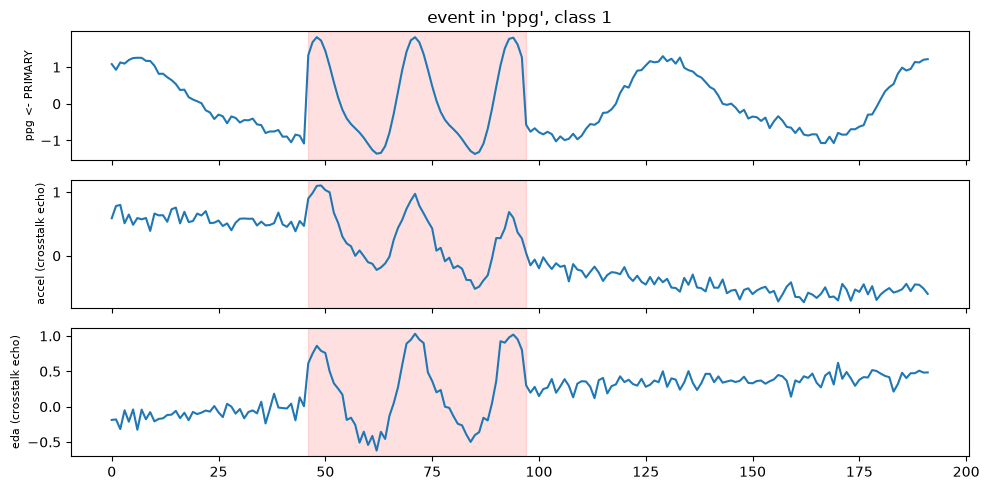

In [2]:
ds = data.make_multivariate_dataset(
    n_samples=600, length=192, crosstalk=0.7, event_sec=0.8, seed=0
)
train_ds, test_ds = data.train_test_split(ds, test_frac=0.25, seed=0)

print("x shape:", ds.x.shape, "channels:", ds.channel_names)
print("classes:", sorted(set(ds.y.tolist())), "(0 = none, 1+c = primary channel c)")

i = np.where(train_ds.y > 0)[0][0]
s, e = train_ds.event_windows[i]
ch = train_ds.event_channels[i]

fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(train_ds.x[i, k])
    ax.axvspan(s, e, color="red", alpha=0.12)
    primary = " <- PRIMARY" if k == ch else " (crosstalk echo)"
    ax.set_ylabel(ds.channel_names[k] + primary, fontsize=8)
axes[0].set_title(f"event in '{ds.channel_names[ch]}', class {train_ds.y[i]}")
plt.tight_layout()
plt.show()

Note the echo: the burst is visible in all three panels. Only the amplitude
distinguishes the true source from its crosstalk, which is what makes the
channel axis a real question rather than a giveaway.

## 2. Train the classifier

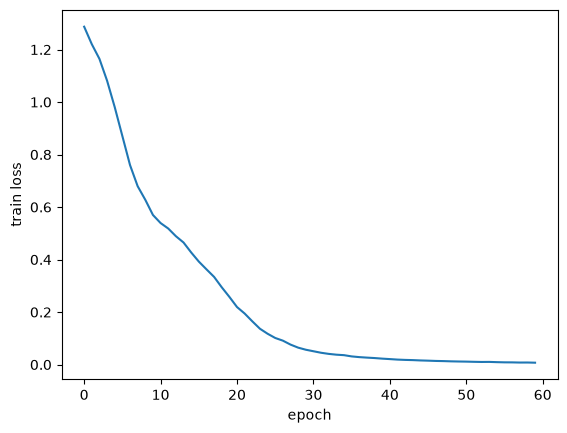

test accuracy: 1.000


In [3]:
clf = model.TSClassifier(n_channels=3, n_classes=4, hidden=32)
losses = model.train(clf, train_ds.x, train_ds.y, epochs=60)

plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("train loss"); plt.show()
print(f"test accuracy: {model.accuracy(clf, test_ds.x, test_ds.y):.3f}")

## 3. How TSR works

Per sample, in three steps:

1. **Time relevance** `dt` — mask *all channels* in a time block, recompute the
   base saliency, take the total absolute change. Large change => that moment
   mattered.
2. **Feature relevance** `d_ct` — only for blocks that clear a threshold, mask
   *one channel* in the block and measure the change again. This asks "given
   this moment matters, which channel carries it?"
3. **Combine** — the final map is the product `dt * d_ct`, so a point must
   score on *both* axes to survive.

Cost is O(T/stride x C) full saliency recomputations, which is why `time_stride`
and a low `ig_steps` matter. Exact per-timestep TSR on a long signal is
genuinely expensive — a real property of the method, not a shortcut here.

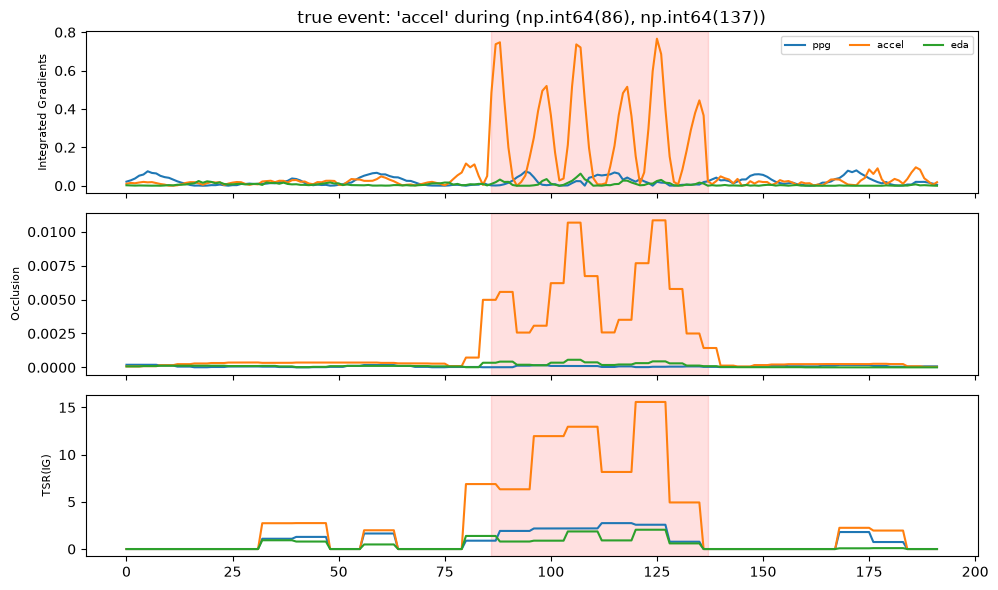

In [4]:
idx = np.where(test_ds.y > 0)[0][0]
x = test_ds.x[idx]
y_true = int(test_ds.y[idx])
window = tuple(test_ds.event_windows[idx])
true_ch = test_ds.event_channels[idx]

maps = {
    "Integrated Gradients": attribution.integrated_gradients(clf, x, y_true),
    "Occlusion": attribution.occlusion(clf, x, y_true),
    "TSR(IG)": attribution.temporal_saliency_rescaling(
        clf, x, y_true, time_stride=8, ig_steps=16
    ),
}

fig, axes = plt.subplots(len(maps), 1, figsize=(10, 6), sharex=True)
for ax, (name, m) in zip(axes, maps.items()):
    for k in range(3):
        ax.plot(np.abs(m[k]), label=ds.channel_names[k])
    ax.axvspan(*window, color="red", alpha=0.12)
    ax.set_ylabel(name, fontsize=8)
axes[0].set_title(f"true event: '{ds.channel_names[true_ch]}' during {window}")
axes[0].legend(fontsize=7, ncol=3)
plt.tight_layout(); plt.show()

## 4. Scoring across the test set

Two metrics, one per axis:

- `top_k_overlap` — IoU of the top-attributed timesteps against the true event
  window. **`k` defaults to the true event length**, not a fixed fraction: a
  fixed fraction silently caps the achievable score whenever the event is longer
  than it (pick 38 timesteps against a 128-sample event and the best possible
  IoU is 38/128). That capping bit us while building this and is worth knowing.
- `channel_hit` — did the method put most attribution mass on the channel that
  actually carried the event?

n event samples: 75

method                   time IoU   channel acc
Integrated Gradients        0.547         1.000
Occlusion                   0.861         0.987
TSR(IG)                     0.706         1.000


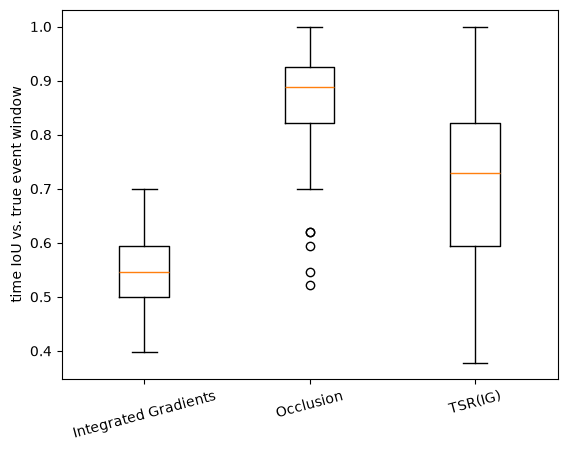

In [5]:
event_idx = np.where(test_ds.y > 0)[0]
methods = {
    "Integrated Gradients": lambda x, t: attribution.integrated_gradients(clf, x, t),
    "Occlusion": lambda x, t: attribution.occlusion(clf, x, t),
    "TSR(IG)": lambda x, t: attribution.temporal_saliency_rescaling(
        clf, x, t, time_stride=8, ig_steps=16
    ),
}

scores = {k: {"iou": [], "ch": []} for k in methods}
for i in event_idx:
    xi, ti = test_ds.x[i], int(test_ds.y[i])
    win, ec = tuple(test_ds.event_windows[i]), test_ds.event_channels[i]
    for name, fn in methods.items():
        m = fn(xi, ti)
        scores[name]["iou"].append(attribution.top_k_overlap(m, win))
        scores[name]["ch"].append(attribution.channel_hit(m, ec))

print(f"n event samples: {len(event_idx)}\n")
print(f"{'method':22s} {'time IoU':>10s} {'channel acc':>13s}")
for name, v in scores.items():
    print(f"{name:22s} {np.mean(v['iou']):10.3f} {np.mean(v['ch']):13.3f}")

plt.boxplot([scores[k]["iou"] for k in methods], tick_labels=list(methods))
plt.ylabel("time IoU vs. true event window"); plt.xticks(rotation=15); plt.show()

## 5. Takeaways

- **TSR improves IG's temporal localization**, which is what it was designed to
  do — the rescaling recovers part of the gap to occlusion. The raw IG map
  spreads credit across timesteps that the time-relevance term then suppresses.
- **The channel axis saturates**: every method scores at or near 1.0, so it does
  not discriminate between them on this data. Reported as-is rather than tuned
  until a gap appears — manufacturing a spread by reverse-engineering the
  generator would prove nothing. The honest reading is that this dataset's
  channel attribution is easy, and TSR's benefit here shows up on the time axis.
- **TSR is not free.** It costs a full saliency recomputation per time block per
  channel. On a long recording with many sensors, that is the dominant cost, and
  the `time_stride` knob is a real accuracy/compute trade-off rather than an
  implementation detail.
- Occlusion remains strong on this task. See the
  [Dynamask notebook](dynamask.ipynb) for the regime where its fixed-window
  assumption starts to cost it something, and where its attribution magnitudes
  stop meaning what you would expect.